In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("pandas:", pd.__version__)

pandas: 3.0.1


In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
print(df.shape)
print(df.head())

(891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN    

In [3]:
# Сколько строк и столбцов
print(df.shape)

# Названия столбцов
print(df.columns.tolist())

# Типы данных каждого столбца
print(df.dtypes)

(891, 12)
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object


In [4]:
# Сколько пустых значений в каждом столбце
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [5]:
# Среднее, медиана, min, max по числовым столбцам
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
total = len(df)
cabin_missing = df['Cabin'].isnull().sum()
cabin_filled = total - cabin_missing
print(f"Всего строк: {total}")
print(f"Cabin заполнен: {cabin_filled}")
print(f"Cabin пустой: {cabin_missing}")
print(f"Процент пропусков: {round(cabin_missing / total * 100, 1)}%")

Всего строк: 891
Cabin заполнен: 204
Cabin пустой: 687
Процент пропусков: 77.1%


In [7]:
# Сколько выжило и сколько погибло
print(df['Survived'].value_counts())

# В процентах
print(df['Survived'].value_counts(normalize=True).round(2))

Survived
0    549
1    342
Name: count, dtype: int64
Survived
0    0.62
1    0.38
Name: proportion, dtype: float64


In [8]:
# Выживаемость по полу
df.groupby('Sex')['Survived'].mean().round(2)

Sex
female    0.74
male      0.19
Name: Survived, dtype: float64

In [9]:
# Выживаемость по классу билета
df.groupby('Pclass')['Survived'].mean().round(2)

Pclass
1    0.63
2    0.47
3    0.24
Name: Survived, dtype: float64

In [10]:
# Средний возраст по классу
df.groupby('Pclass')['Age'].mean().round(1)

Pclass
1    38.2
2    29.9
3    25.1
Name: Age, dtype: float64

In [12]:
# Средняя цена билета по классу
df.groupby('Pclass')['Fare'].mean().round(2)

Pclass
1    84.15
2    20.66
3    13.68
Name: Fare, dtype: float64

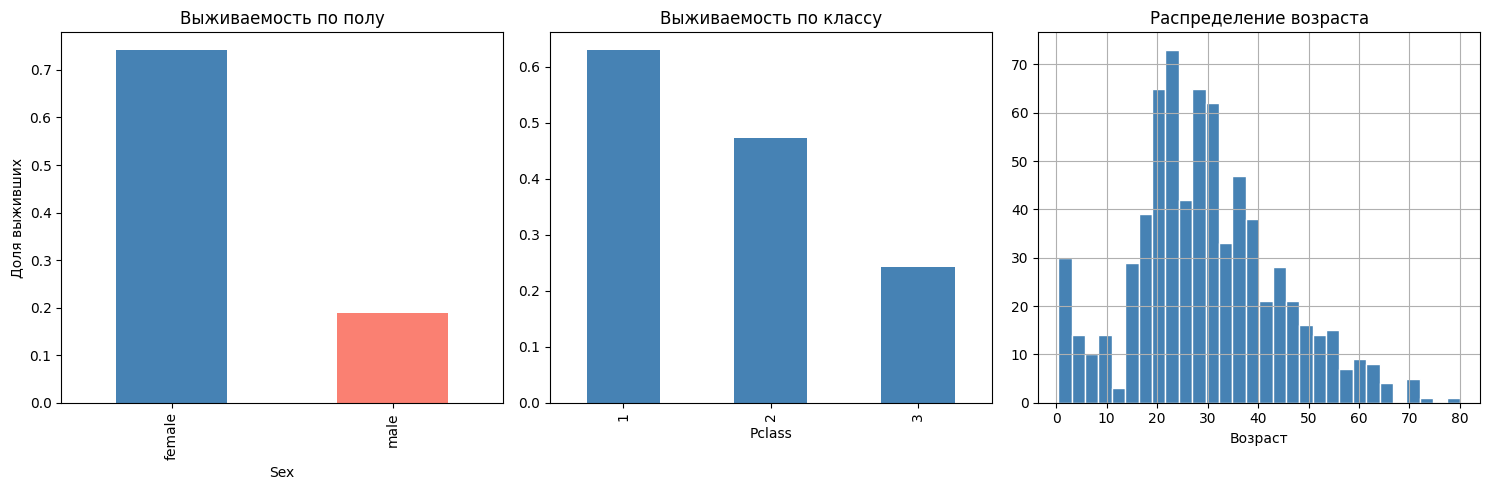

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# График 1: выживаемость по полу
df.groupby('Sex')['Survived'].mean().plot(
    kind='bar', ax=axes[0], color=['steelblue', 'salmon']
)
axes[0].set_title('Выживаемость по полу')
axes[0].set_ylabel('Доля выживших')

# График 2: выживаемость по классу
df.groupby('Pclass')['Survived'].mean().plot(
    kind='bar', ax=axes[1], color='steelblue'
)
axes[1].set_title('Выживаемость по классу')

# График 3: распределение возраста
df['Age'].hist(bins=30, ax=axes[2], color='steelblue', edgecolor='white')
axes[2].set_title('Распределение возраста')
axes[2].set_xlabel('Возраст')

plt.tight_layout()
plt.show()

In [14]:
df.groupby('Survived')['Age'].mean().round(1)

Survived
0    30.6
1    28.3
Name: Age, dtype: float64